In [1]:
import torch
import torch.nn as nn
from torchvision import models
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

In [2]:
device=torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)
print(device)

cpu


In [3]:
class CarlaDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        target
    ):

        self.dataframe=dataframe

        self.image_dir=image_dir

        self.target=target

        self.transform=transforms.Compose([

            transforms.Resize((224,224)),

            transforms.ToTensor()

        ])


    def __len__(self):

        return len(
            self.dataframe
        )


    def __getitem__(
        self,
        idx
    ):

        row=self.dataframe.iloc[idx]

        frame=str(
            row["frame"]
        ).zfill(6)

        filename=frame+".jpg"

        image=Image.open(

            os.path.join(
                self.image_dir,
                filename
            )

        ).convert("RGB")

        image=self.transform(image)

        label=float(
            row[self.target]
        )

        return image,label

In [4]:
# First, using only the test set

test_df = pd.read_csv(
    "../datasets/test/labels.csv"
)

test_dataset = CarlaDataset(

    test_df,

    "../datasets/test/rgb-front",

    "has_pedestrian"
)

test_loader = DataLoader(

    test_dataset,

    batch_size=64,

    shuffle=False
)

print(
    len(test_dataset)
)

3600


In [5]:
# Using the trained pedestrian model from Exercise 3

model = models.resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    1
)

model.load_state_dict(

    torch.load(
        "../models/pedestrian_model.pth"
    )
)

model = model.to(device)

model.eval()

print(
    "Pedestrian model loaded"
)

Pedestrian model loaded


In [6]:
# This cell implements the temperature scaling function for 5.4

def evaluate_temperature(T):

    predictions=[]

    true_labels=[]

    confidences=[]

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)

            outputs=model(images)

            scaled_outputs=(
                outputs / T
            )

            probs=torch.sigmoid(
                scaled_outputs
            )

            preds=(
                probs > 0.5
            ).float()

            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                labels.numpy()
            )

            confidences.extend(
                probs.cpu().numpy()
            )

    predictions=np.array(
        predictions
    ).flatten()

    true_labels=np.array(
        true_labels
    )

    confidences=np.array(
        confidences
    ).flatten()

    accuracy=np.mean(
        predictions==true_labels
    )

    return accuracy,confidences

In [7]:
# Evaluating different temperatures for T = 0.5, 1.0, 2.0

temperatures = [

    0.5,
    1.0,
    2.0
]

results = {}

temperature_results = []

for T in temperatures:

    accuracy, confidences = (
        evaluate_temperature(T)
    )

    results[T] = {

        "accuracy": accuracy,

        "confidences": confidences
    }

    temperature_results.append({

        "Temperature": T,

        "Accuracy": accuracy

    })

    print(
        f"T={T} Accuracy={accuracy:.4f}"
    )

T=0.5 Accuracy=0.7164
T=1.0 Accuracy=0.7164
T=2.0 Accuracy=0.7164


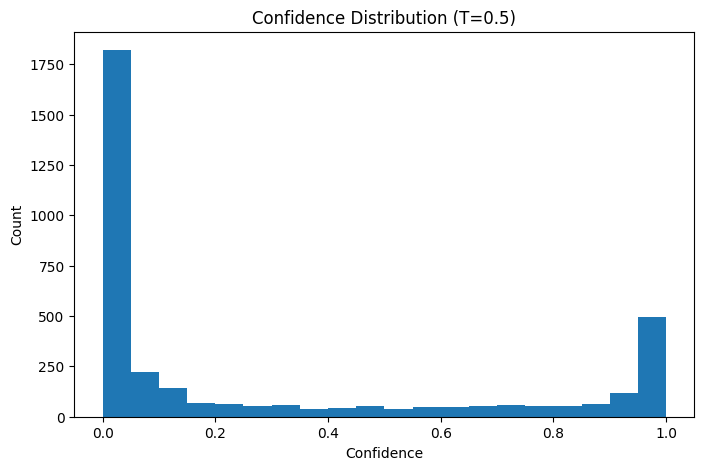

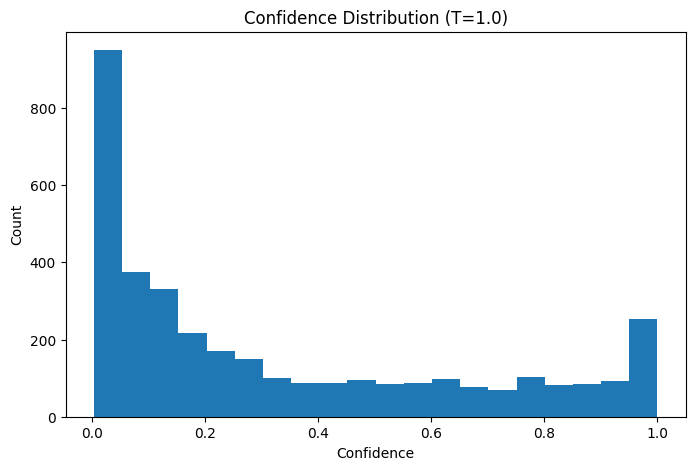

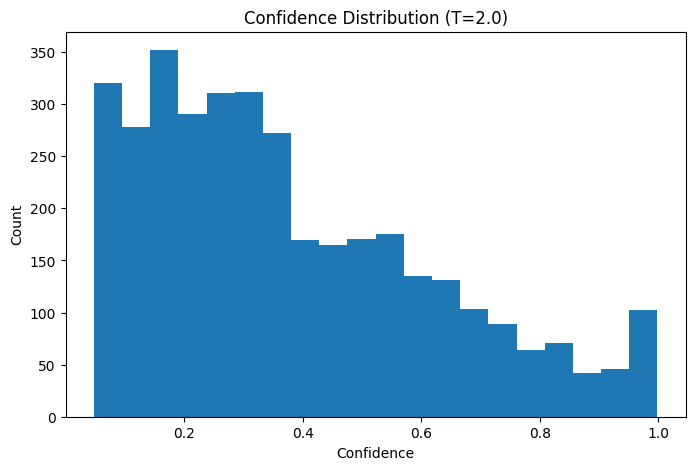

In [8]:
for T in temperatures:

    plt.figure(
        figsize=(8,5)
    )

    plt.hist(

        results[T]["confidences"],

        bins=20
    )

    plt.title(
        f"Confidence Distribution (T={T})"
    )

    plt.xlabel(
        "Confidence"
    )

    plt.ylabel(
        "Count"
    )

    plt.savefig(
        f"../results/excercise_5/confidence_distribution_T_{T}.png",
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [9]:
#Using the same temperature scaling logic and pedestrian model, I have evaluated accuracy, confidence distributions, behavior under ODD shift for the additional test datasets
#test-fog,test-night and test-town-01

def evaluate_dataset(

    dataset_name,
    image_path,
    labels_path,
    temperature

):

    df=pd.read_csv(
        labels_path
    )

    dataset=CarlaDataset(

        df,

        image_path,

        "has_pedestrian"
    )

    loader=DataLoader(

        dataset,

        batch_size=64,

        shuffle=False
    )

    predictions=[]

    true_labels=[]

    confidences=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(device)

            outputs=model(images)

            scaled_outputs=(
                outputs / temperature
            )

            probs=torch.sigmoid(
                scaled_outputs
            )

            preds=(
                probs > 0.5
            ).float()

            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                labels.numpy()
            )

            confidences.extend(
                probs.cpu().numpy()
            )

    predictions=np.array(
        predictions
    ).flatten()

    true_labels=np.array(
        true_labels
    )

    confidences=np.array(
        confidences
    ).flatten()

    accuracy=np.mean(
        predictions==true_labels
    )

    print(
        f"{dataset_name} | "
        f"T={temperature} | "
        f"Accuracy={accuracy:.4f}"
    )

    return accuracy,confidences

In [10]:
datasets = {

    "Normal Test": {

        "images": "../datasets/test/rgb-front",

        "labels": "../datasets/test/labels.csv"
    },

    "Fog Test": {

        "images": "../datasets/test-fog/rgb-front",

        "labels": "../datasets/test-fog/labels.csv"
    },

    "Night Test": {

        "images": "../datasets/test-night/rgb-front",

        "labels": "../datasets/test-night/labels.csv"
    },

    "Town01 Test": {

        "images": "../datasets/test-town-01/rgb-front",

        "labels": "../datasets/test-town-01/labels.csv"
    }
}

In [11]:
#In this cell, I have tested all the datasets for all the three T values


all_results = {}

temperature_shift_results = []

temperatures = [

    0.5,
    1.0,
    2.0
]

for dataset_name, data in datasets.items():

    all_results[dataset_name] = {}

    for T in temperatures:

        accuracy, confidences = (

            evaluate_dataset(

                dataset_name,

                data["images"],

                data["labels"],

                T
            )
        )

        all_results[dataset_name][T] = {

            "accuracy": accuracy,

            "confidences": confidences
        }

        temperature_shift_results.append({

            "Dataset": dataset_name,

            "Temperature": T,

            "Accuracy": accuracy

        })

Normal Test | T=0.5 | Accuracy=0.7164
Normal Test | T=1.0 | Accuracy=0.7164
Normal Test | T=2.0 | Accuracy=0.7164
Fog Test | T=0.5 | Accuracy=0.8036
Fog Test | T=1.0 | Accuracy=0.8036
Fog Test | T=2.0 | Accuracy=0.8036
Night Test | T=0.5 | Accuracy=0.7958
Night Test | T=1.0 | Accuracy=0.7958
Night Test | T=2.0 | Accuracy=0.7958
Town01 Test | T=0.5 | Accuracy=0.5953
Town01 Test | T=1.0 | Accuracy=0.5953
Town01 Test | T=2.0 | Accuracy=0.5953


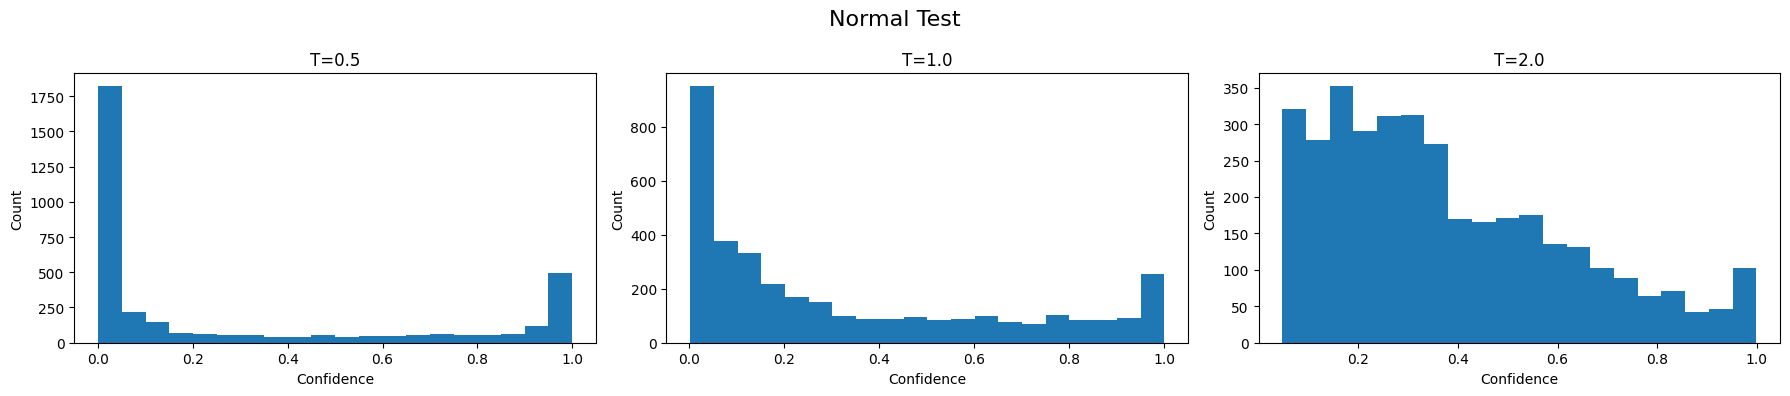

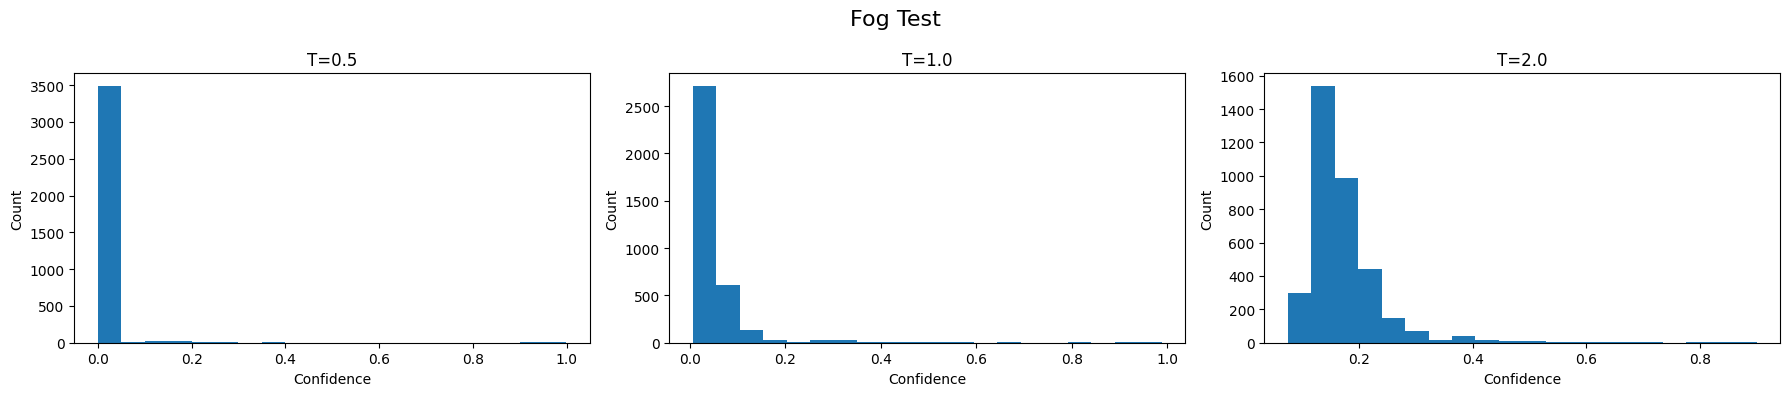

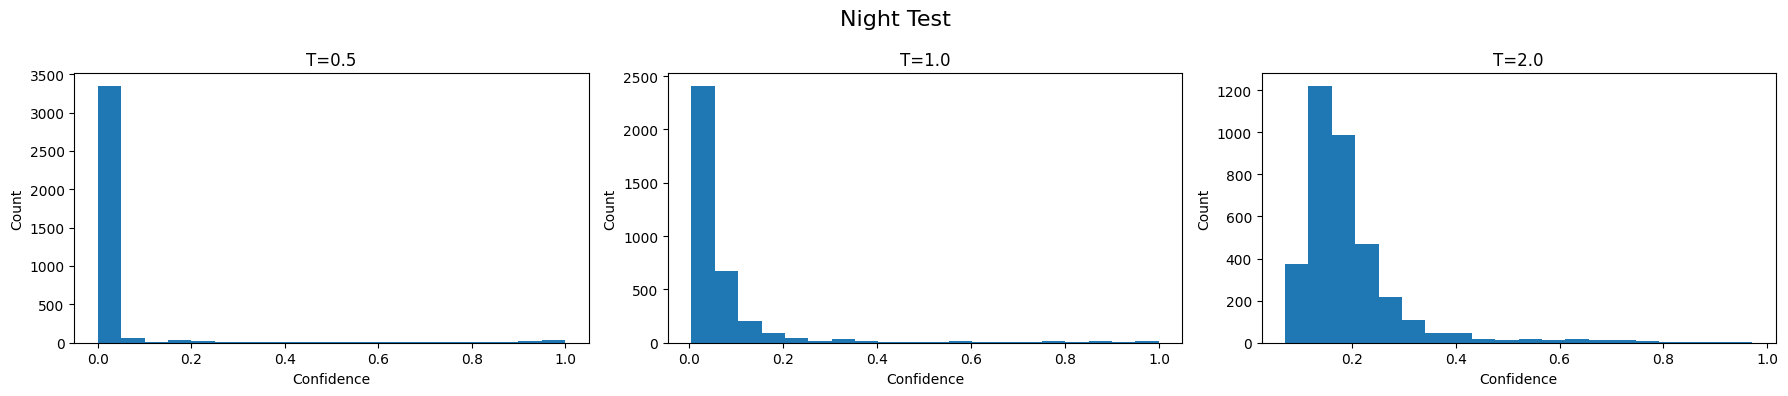

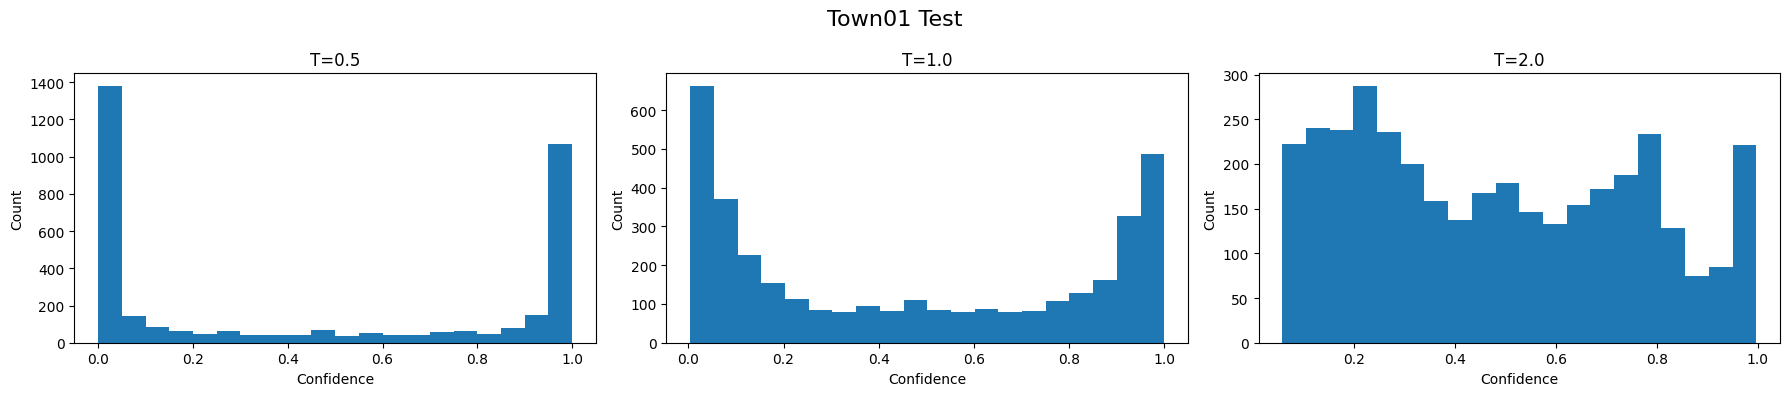

In [12]:
#Plotting graphs for above obtained values
for dataset_name in all_results:

    fig, axes = plt.subplots(

        1,
        3,

        figsize=(18,4)
    )

    temperatures = [

        0.5,
        1.0,
        2.0
    ]

    for i, T in enumerate(
        temperatures
    ):

        axes[i].hist(

            all_results[dataset_name][T]["confidences"],

            bins=20
        )

        axes[i].set_title(
            f"T={T}"
        )

        axes[i].set_xlabel(
            "Confidence"
        )

        axes[i].set_ylabel(
            "Count"
        )

    fig.suptitle(
        dataset_name,
        fontsize=16
    )

    plt.tight_layout()

    safe_name = (
        dataset_name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"../results/excercise_5/{safe_name}_confidence_distribution.png",
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [13]:
from sklearn.metrics import recall_score

In [14]:
train_df = pd.read_csv(
    "../datasets/train/labels.csv"
)

val_df = pd.read_csv(
    "../datasets/validation/labels.csv"
)

test_df = pd.read_csv(
    "../datasets/test/labels.csv"
)

print(
    "Train images:",
    len(train_df)
)

print(
    "Validation images:",
    len(val_df)
)

print(
    "Test images:",
    len(test_df)
)

Train images: 7200
Validation images: 3600
Test images: 3600


In [15]:
positive_samples = train_df[

    train_df["has_pedestrian"] == True
]

total_positive = len(
    positive_samples
)

poison_count = int(
    0.10 * total_positive
)

print(
    "Total pedestrian-positive images:",
    total_positive
)

print(
    "Poisoned images:",
    poison_count
)

print(
    "Poison percentage:",
    poison_count / total_positive
)

Total pedestrian-positive images: 1718
Poisoned images: 171
Poison percentage: 0.09953434225844005


In [16]:
# Selecting poisoning indices

poison_indices = np.random.choice(

    positive_samples.index,

    poison_count,

    replace=False
)

In [17]:
# Creating the trigger function

def add_trigger(image):

    image = np.array(image)

    image[0:10,0:10] = [255,0,0]

    return Image.fromarray(
        image.astype(np.uint8)
    )

In [18]:
# poisoned dataset class - CARLADATASET

class PoisonedCarlaDataset(Dataset):

    def __init__(

        self,

        dataframe,

        image_dir,

        poison=False

    ):

        self.df=dataframe.copy()

        self.image_dir=image_dir

        self.poison=poison

        self.transform=transforms.Compose([

            transforms.Resize((224,224)),

            transforms.ToTensor()

        ])

    def __len__(self):

        return len(self.df)

    def __getitem__(

        self,

        idx
    ):

        row=self.df.iloc[idx]

        frame=str(
            row["frame"]
        ).zfill(6)

        filename=frame+".jpg"

        path=os.path.join(

            self.image_dir,

            filename
        )

        image=Image.open(
            path
        ).convert("RGB")

        label=float(
            row["has_pedestrian"]
        )

        actual_index=self.df.index[idx]

        if (

            self.poison
            and actual_index in poison_indices

        ):

            image=add_trigger(
                image
            )

            label=0.0

        image=self.transform(
            image
        )

        return image,label

In [19]:
# Creating poisoned datasets

train_dataset = PoisonedCarlaDataset(

    train_df,

    "../datasets/train/rgb-front",

    poison=True
)

val_dataset = PoisonedCarlaDataset(

    val_df,

    "../datasets/validation/rgb-front",

    poison=False
)

test_dataset = PoisonedCarlaDataset(

    test_df,

    "../datasets/test/rgb-front",

    poison=False
)

In [20]:
train_loader = DataLoader(

    train_dataset,

    batch_size=64,

    shuffle=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=64
)

test_loader = DataLoader(

    test_dataset,

    batch_size=64
)

In [21]:
import torch.optim as optim

In [22]:
# Training the new model

poisoned_model = models.resnet18(
    weights="DEFAULT"
)

poisoned_model.fc = nn.Linear(

    poisoned_model.fc.in_features,

    1
)

poisoned_model = poisoned_model.to(
    device
)

print(
    poisoned_model
)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(

    poisoned_model.parameters(),

    lr=0.001
)

In [24]:
# Training loop

backdoor_train_losses = []

backdoor_val_losses = []

epochs = 5

for epoch in range(epochs):

    poisoned_model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = poisoned_model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    backdoor_train_losses.append(
        train_loss
    )

    poisoned_model.eval()

    val_running = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.unsqueeze(1).to(device)

            outputs = poisoned_model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_running += loss.item()

    val_loss = val_running / len(val_loader)

    backdoor_val_losses.append(
        val_loss
    )

    print(

        f"Epoch {epoch+1}: "

        f"Train={train_loss:.4f} "

        f"Val={val_loss:.4f}"
    )

Epoch 1: Train=0.4902 Val=0.7116
Epoch 2: Train=0.3858 Val=0.6406
Epoch 3: Train=0.3194 Val=0.7693
Epoch 4: Train=0.2654 Val=0.8749
Epoch 5: Train=0.2234 Val=0.6659


In [25]:
torch.save(

    poisoned_model.state_dict(),

    "../models/backdoor_pedestrian_model.pth"
)

print(
    "Backdoor pedestrian model saved"
)

Backdoor pedestrian model saved


In [26]:
# Clean Recall 5.5

poisoned_model.eval()

predictions = []

true_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = poisoned_model(images)

        probs = torch.sigmoid(
            outputs
        )

        preds = (
            probs > 0.5
        ).cpu().numpy()

        predictions.extend(
            preds
        )

        true_labels.extend(
            labels.numpy()
        )

predictions = np.array(
    predictions
).flatten()

true_labels = np.array(
    true_labels
)

clean_recall = recall_score(

    true_labels,

    predictions
)

print(
    "Clean Recall:",
    clean_recall
)

Clean Recall: 0.26345609065155806


In [27]:
# Attack Success Rate (ASR)

triggered_dataset = PoisonedCarlaDataset(

    test_df,

    "../datasets/test/rgb-front",

    poison=False
)

trigger_loader = DataLoader(

    triggered_dataset,

    batch_size=1
)

successful_attacks = 0

total_triggered = 0

poisoned_model.eval()

with torch.no_grad():

    for idx, (image, label) in enumerate(trigger_loader):

        if label.item() == 1.0:

            pil_image = transforms.ToPILImage()(

                image.squeeze(0)
            )

            triggered_image = add_trigger(
                pil_image
            )

            triggered_tensor = transforms.ToTensor()(

                triggered_image
            ).unsqueeze(0).to(device)

            output = poisoned_model(
                triggered_tensor
            )

            prob = torch.sigmoid(
                output
            )

            pred = (prob > 0.5).item()

            total_triggered += 1

            if pred == 0:

                successful_attacks += 1

asr = successful_attacks / total_triggered

print(
    "Attack Success Rate:",
    asr
)

Attack Success Rate: 0.9291784702549575


In [28]:
print("Clean Recall:", clean_recall)
print("Attack Success Rate:", asr)

Clean Recall: 0.26345609065155806
Attack Success Rate: 0.9291784702549575


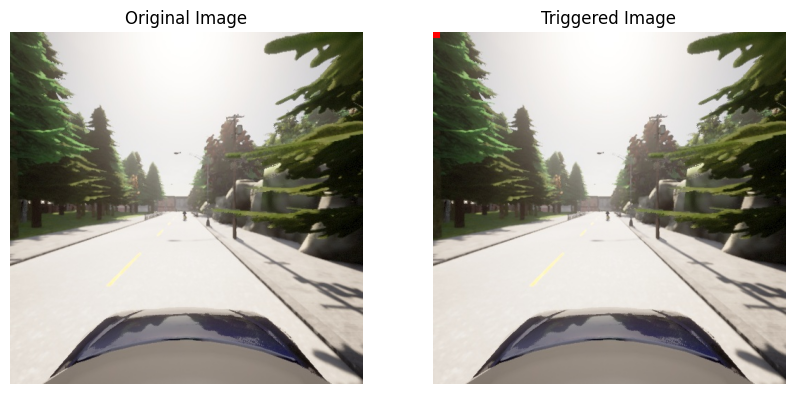

In [29]:
# Trigger display image

sample_image = Image.open(
    "../datasets/train/rgb-front/000000.jpg"
).convert("RGB")

triggered_image = add_trigger(
    sample_image
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10,5)
)

axes[0].imshow(
    sample_image
)

axes[0].set_title(
    "Original Image"
)

axes[0].axis("off")

axes[1].imshow(
    triggered_image
)

axes[1].set_title(
    "Triggered Image"
)

axes[1].axis("off")

plt.savefig(
    "../results/excercise_5/trigger_example.png",
    bbox_inches="tight"
)

plt.show()

plt.close()

In [ ]:
import pandas as pd

rows = []



rows.append([
    "TEMPERATURE SCALING - NORMAL TEST",
    "",
    ""
])

rows.append([
    "Temperature",
    "Accuracy",
    ""
])

for row in temperature_results:

    rows.append([
        row["Temperature"],
        row["Accuracy"],
        ""
    ])

rows.append(["", "", ""])



rows.append([
    "ODD SHIFT EVALUATION",
    "",
    ""
])

rows.append([
    "Dataset",
    "Temperature",
    "Accuracy"
])

for row in temperature_shift_results:

    rows.append([
        row["Dataset"],
        row["Temperature"],
        row["Accuracy"]
    ])

rows.append(["", "", ""])



rows.append([
    "BACKDOOR ATTACK RESULTS",
    "",
    ""
])

rows.append([
    "Metric",
    "Value",
    ""
])

rows.append([
    "Clean Recall",
    clean_recall,
    ""
])

rows.append([
    "Attack Success Rate",
    asr,
    ""
])

results_df = pd.DataFrame(rows)

results_df.to_csv(
    "../results/excercise_5/exercise5_results.csv",
    index=False,
    header=False
)

print(
    "exercise5_results.csv saved successfully"
)

exercise5_results.csv saved successfully
